<a href="https://colab.research.google.com/github/GeorgieWasTaken/marmeladki/blob/main/Task2_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Урок: Визуализация данных с помощью Pandas и Matplotlib
# 📖 Теоретический минимум
## 🔹 Основные библиотеки визуализации
Matplotlib - базовая библиотека для создания статических, анимированных и интерактивных визуализаций

Pandas - встроенные методы визуализации на основе Matplotlib

Seaborn - библиотека для создания статистических графиков (работает поверх Matplotlib)

## 🔹 Типы графиков и их применение
Линейные графики - тенденции изменения во времени

Столбчатые диаграммы - сравнение категориальных данных

Круговые диаграммы - доли составных частей

Гистограммы - распределение данных

Точечные диаграммы - взаимосвязь между двумя переменными

## 🔹 Основные принципы хорошей визуализации
Простота и ясность

Правильный выбор типа графика

Адекватные подписи и легенда

Оптимальное использование цвета

Отсутствие визуального шума


## 📖 Материалы

https://vkvideo.ru/video-194554202_456239677

https://vkvideo.ru/playlist/-16108331_55984952








In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Загрузка данных из файла Excel
url = 'https://docs.google.com/spreadsheets/d/1y9ekfl_0NOFLQtwqzXcJdijcMqquSDUn_XqtW-S7R3Q/export?format=xlsx'

# Чтение листов в два отдельных DataFrame
reservoir_df = pd.read_excel(url, sheet_name='Reservoir', index_col=False)
wells_df = pd.read_excel(url, sheet_name='Wells', index_col=False, names=['date',	'field_id',	'well_id', 'oil',	'gas',	'water'])


# 🏆 Задания

## 1️⃣ Линейный график динамики добычи нефти
**Задача:**
 Напишите функцию принимающую месторождение и имя скважины и формирующую график добычи нефти по годам

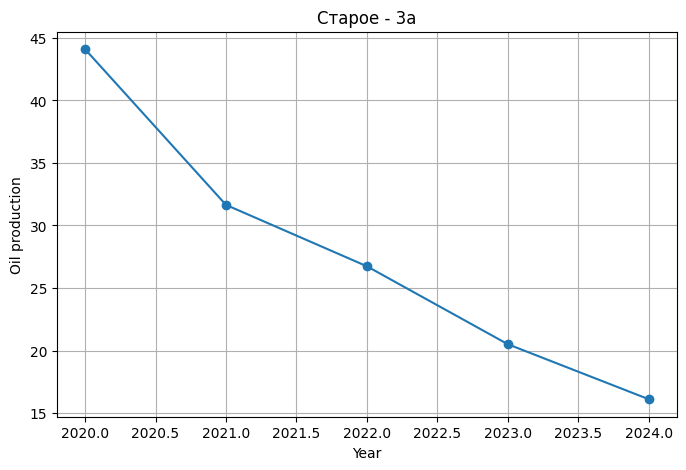

In [26]:
wells_df['date'] = pd.to_datetime(wells_df['date'], errors='coerce')
wells_df = wells_df.dropna(subset=['date'])

wells_df['year'] = wells_df['date'].dt.year


def plot_oil_dynamics(field_name, well_name):

    data = wells_df[
        (wells_df['field_id'] == field_name) &
        (wells_df['well_id'] == well_name)
    ]

    if data.empty:
        print("Нет данных")
        return

    plot_data = data.groupby('year')['oil'].sum()

    plt.figure(figsize=(8, 5))
    plt.plot(plot_data.index, plot_data.values, marker='o')

    plt.xlabel('Year')
    plt.ylabel('Oil production')
    plt.title(f'{field_name} - {well_name}')
    plt.grid()

    plt.show()


plot_oil_dynamics('Старое', '3а')


## 2️⃣ Столбчатая диаграмма

**Задача:**

Напишите функцию формирующую cравнение добычи по месторождениям (столбчатая диаграмма)




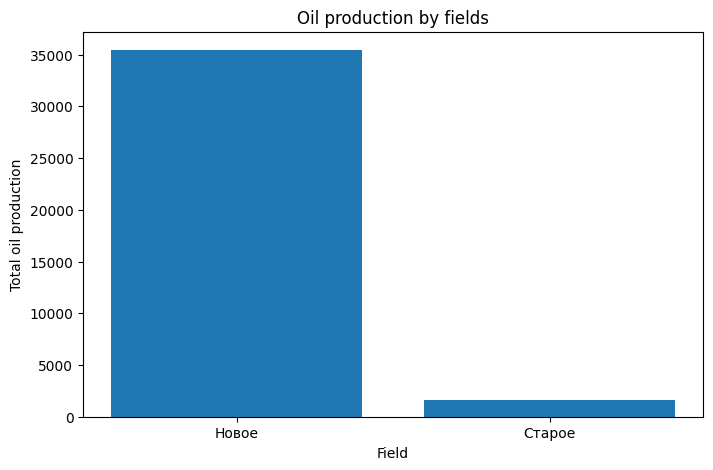

In [28]:
def plot_field_comparison():

    plot_data = wells_df.groupby('field_id')['oil'].sum()

    plt.figure(figsize=(8, 5))

    plt.bar(
        plot_data.index,
        plot_data.values
    )

    plt.xlabel('Field')
    plt.ylabel('Total oil production')
    plt.title('Oil production by fields')

    plt.show()

plot_field_comparison()

## 3️⃣  Круговая диаграмма
**Задача:**Напишите функцию формирующую визуализацию накопленной добычи нефти по скважинам одного месторождения (круговая диаграмма)

---



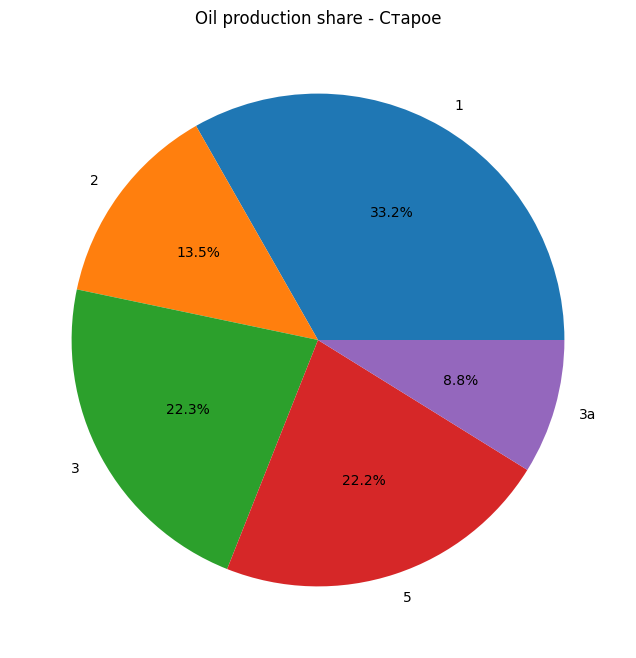

In [8]:
def plot_pie_chart(field_name):

    data = wells_df[
        wells_df['field_id'] == field_name
    ]

    plot_data = data.groupby('well_id')['oil'].sum()

    plt.figure(figsize=(8, 8))

    plt.pie(
        plot_data.values,
        labels=plot_data.index,
        autopct='%1.1f%%'
    )

    plt.title(f'Oil production share - {field_name}')

    plt.show()

plot_pie_chart('Старое')


## 4️⃣   Tornado plot


**Задача:**  Постройте tornado plot для визуализации накопленной добычи жидкости для каждой скважины.
---




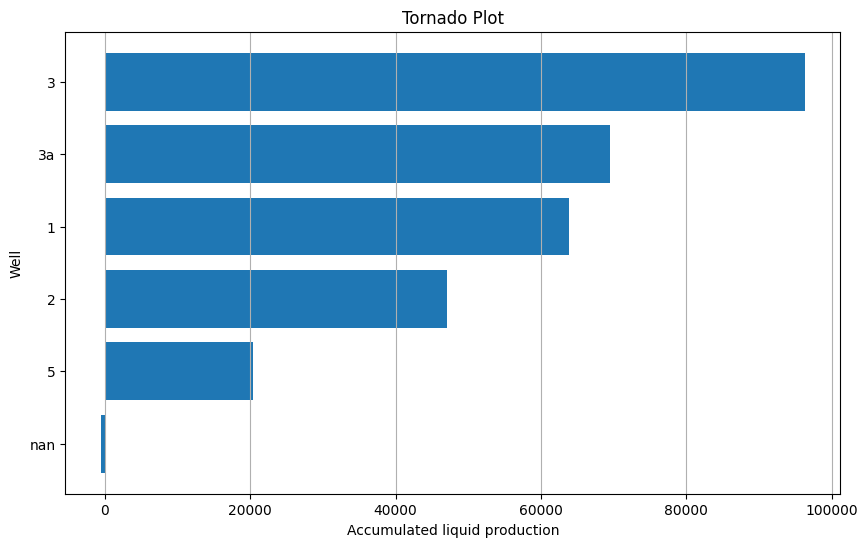

In [47]:



plot_data = wells_df.groupby('well_id')[
    ['oil', 'water']
].sum()

plot_data['liquid'] = (
    plot_data['oil'] +
    plot_data['water']
)

plot_data = plot_data.sort_values(
    by='liquid'
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index.astype(str),
    plot_data['liquid']
)

plt.xlabel('Accumulated liquid production')
plt.ylabel('Well')
plt.title('Tornado Plot')

plt.grid(axis='x')

plt.show()


## 5️⃣ 3D визуализации
**Задача:**

Создайте изображение в 3D для отображения каждой скважины в осях накопленный дебит нефти, газа, воды

---


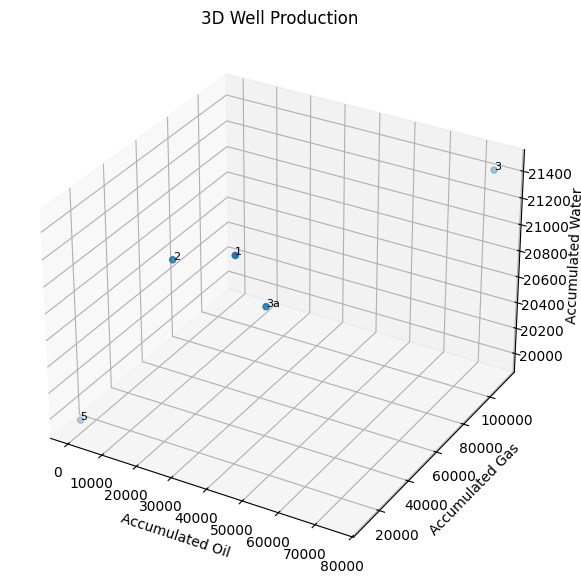

In [48]:
from mpl_toolkits.mplot3d import Axes3D

wells_df['well_id'] = wells_df['well_id'].astype(str).str.strip()

wells_df['oil'] = pd.to_numeric(
    wells_df['oil'],
    errors='coerce'
)

wells_df['gas'] = pd.to_numeric(
    wells_df['gas'],
    errors='coerce'
)

wells_df['water'] = pd.to_numeric(
    wells_df['water'],
    errors='coerce'
)

wells_df = wells_df.dropna(
    subset=['well_id', 'oil', 'gas', 'water']
)

plot_data = wells_df.groupby('well_id')[
    ['oil', 'gas', 'water']
].sum()

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(projection='3d')

x = plot_data['oil']
y = plot_data['gas']
z = plot_data['water']

ax.scatter(x, y, z)

for well, x_val, y_val, z_val in zip(
    plot_data.index,
    x,
    y,
    z
):
    ax.text(
        x_val,
        y_val,
        z_val,
        well,
        fontsize=8
    )

ax.set_xlabel('Accumulated Oil')
ax.set_ylabel('Accumulated Gas')
ax.set_zlabel('Accumulated Water')

plt.title('3D Well Production')

plt.show()
